In [4]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

We have loaded the Dataset. Dataset link: Dataset link :https://www.kaggle.com/devashish0507/big-mart-sales-prediction?select=Train.csv

In [5]:
sales_data = pd.read_csv('Datasets/Sales_Mart.csv')

sales_data.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
sales_data.shape

(8523, 12)

In [9]:
sales_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Note that  the output is a Facet Grid Object.So,The Catplot function is a Figure level function and the plot is built on top of a FacetGrid Object. The above plot is a Strip plot( default in catplot) which is categorical scatterplot where one of the variable is categorical.Same plot can drawn by using stripplot() function. 
Here, We have taken 'Outlet_Type' as the categorical variable in X-axis having three categories 'Supermarket Type1','Supermarket Type2','Supermarket Type3','Grocery Store'   and 'Item_Outlet_Sales' in Y axis. Every data points is plotted with a bit of jitter. The density of data points seem to be higher in 'Supermarket Type1' and 'Grocery Store' compared to the other categories.The data points for 'Grocery Store' are concentrated and have lower sales values compared to others. Few outliers for Sales value for  'Supermarket Type3' are  observed.

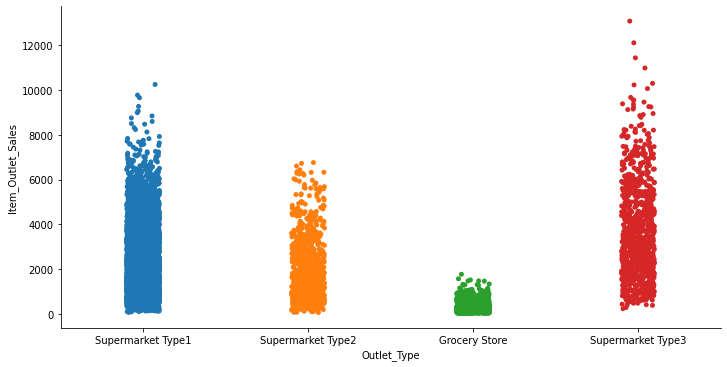

In [10]:
sns.catplot(x = 'Outlet_Type', y = 'Item_Outlet_Sales', 
            data = sales_data , aspect = 2)

Here, We have taken 'Outlet_Type' in X axis and 'Item_Visibility' in Y-axis .Item visibilty for 'Grocery Store' is having high range of values. We can also specify the order of categorical axis by specifying them in order argument.

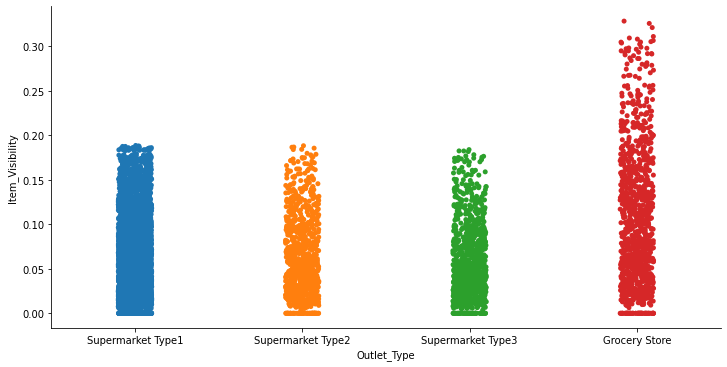

In [11]:
sns.catplot(x = 'Outlet_Type', y = 'Item_Visibility', 
            order = ['Supermarket Type1','Supermarket Type2',
                     'Supermarket Type3','Grocery Store'], 
            data = sales_data, aspect = 2)

We have drawn a strip plot taking 'Outlet_Size' as categorical variable in X axis and 'Item_Outlet_Sales' in Y axis.
High Item sales Values are observed for 'Medium' type of 'Outlet Size'.

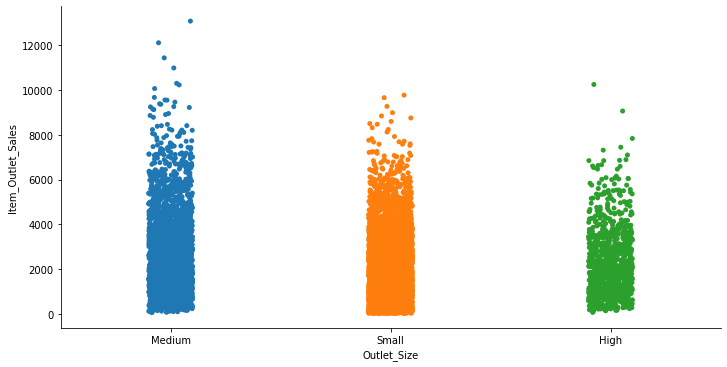

In [12]:
sns.catplot(x = 'Outlet_Size', y = 'Item_Outlet_Sales', 
            data = sales_data, aspect = 2)

Same Strip plot drawn using stripplot function, which is axes level function and the plot is built on top of a matplotlib axes. 

<AxesSubplot:xlabel='Outlet_Size', ylabel='Item_Outlet_Sales'>

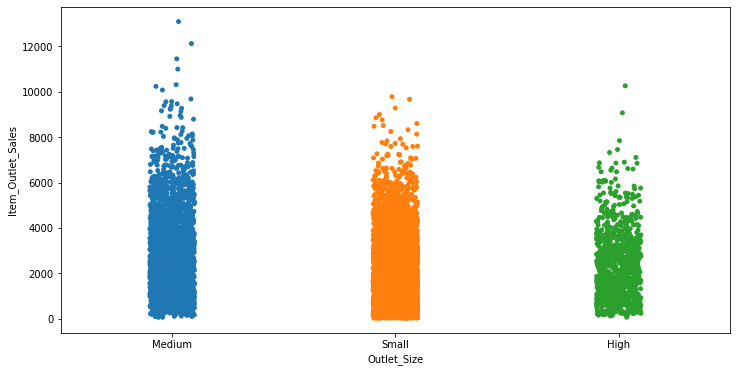

In [13]:
f, ax = plt.subplots(figsize = (12, 6))

sns.stripplot(x = 'Outlet_Size', y = 'Item_Outlet_Sales', data = sales_data)

We have drawn a strip plot taking 'Outlet_Location_Type' as categorical variable in X axis and 'Item_Outlet_Sales' in Y axis. The jitter is disabled using jitter=False and here is a  stripplot where data points are overlapping.The distribution of data points is not clear due to the removal of jitter.

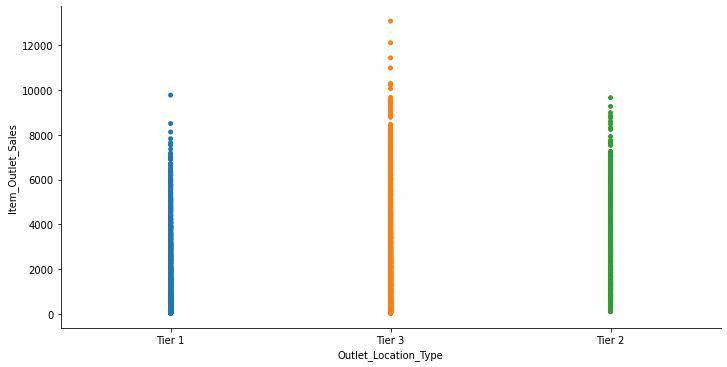

In [14]:
sns.catplot(x = 'Outlet_Location_Type', y = 'Item_Outlet_Sales', 
            jitter = False, data = sales_data, aspect = 2)

We can also add additional variables in strip plot using 'hue','row', and 'col' arguments. But swarm plot is preferred for this purpose as data points are overlapping in case of stripplot.  Here in the above plot, We have added 'Outlet_Type' as hue and 'Outlet_Size' as 'row' argument

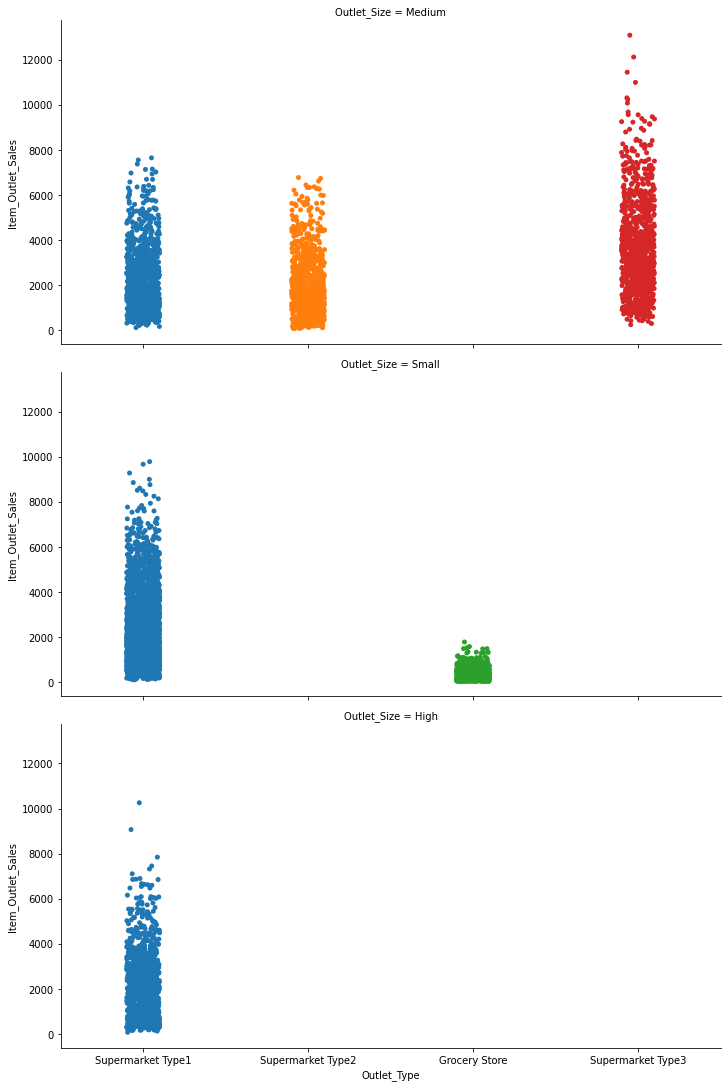

In [19]:
sns.catplot(x = 'Outlet_Type', y = 'Item_Outlet_Sales', 
            row = 'Outlet_Size',
            data = sales_data, aspect = 2);

The below plot is a Swarm plot which is similar to strip plot but points don't overlap. We have drawn a swarm plot using Catplot function by setting 'kind' to 'swarm'.We have taken  'Item_Type' as categorical variable in X axis and 'Item_Visibility' in Y axis. All the data points are visible with no overlapping. High item visibility observed in some data for 'Canned', 'Household' and 'Fruits& Vegetables' item type. 


In [23]:
sales_data['Item_Type'].value_counts()

Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: Item_Type, dtype: int64

In [30]:
selected_items = ['Fruits and Vegetables', 'Snack Foods',
                 'Seafood', 'Hard Drinks']

selected_items_sales_data = sales_data[sales_data['Item_Type'].isin(selected_items)]

selected_items_sales_data['Item_Type'].value_counts()

Fruits and Vegetables    1232
Snack Foods              1200
Hard Drinks               214
Seafood                    64
Name: Item_Type, dtype: int64

/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 28.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 26.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


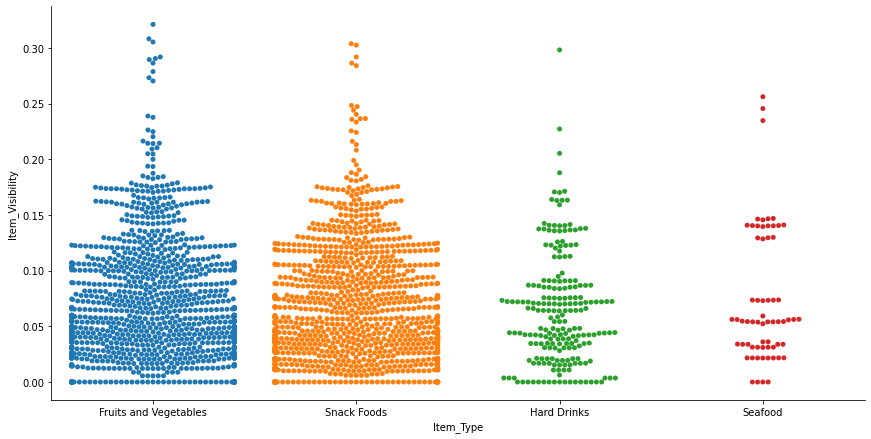

In [34]:
sns.catplot(x = 'Item_Type', y = 'Item_Visibility', kind = 'swarm', 
            data = selected_items_sales_data, height = 6, aspect = 2);

Same Swarmplot can also be drawn by using swarmplot() function,which is axes level function and the plot is built on top of a matplotlib axes.

/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 16.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 12.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


<AxesSubplot:xlabel='Item_Type', ylabel='Item_MRP'>

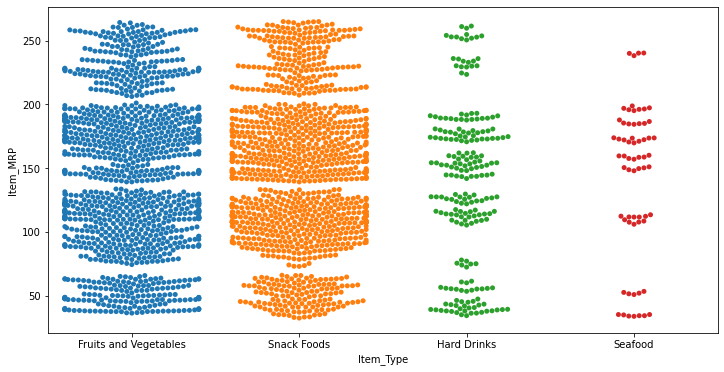

In [36]:
f, ax = plt.subplots(figsize = (12, 6))

sns.swarmplot(x = 'Item_Type', y = 'Item_MRP', data = selected_items_sales_data)

Here, We have drawn a swarm plot taking 'Outlet_Establishment_Year' as categorical variable in X axis and 'Item_Outlet_Sales' in Y axis. We have added another variable 'Outlet_Size' as hue. The distribution of data points  for both levels of churn is different.By zooming into the plot, It can be clearly observed that Sales Values for Medium Size Outlet established in 1985 are higher than the other outlets.Outlet established in 1998 is having Lowest Item Sales values and also number of transactions. Outlet established in 1987 is having High Outlet Size.Similarly, Outlets established in 1997,1999,2004,2009 are small,medium,small,and medium sized respectively.


In [37]:
sales_data['Outlet_Establishment_Year'].value_counts()

1985    1463
1987     932
1999     930
1997     930
2004     930
2002     929
2009     928
2007     926
1998     555
Name: Outlet_Establishment_Year, dtype: int64

In [44]:
selected_years = ['1985', '1987',
                  '1999',
                  '2009']

selected_years_sales_data = sales_data[\
    sales_data['Outlet_Establishment_Year'].isin(selected_years)]

selected_years_sales_data['Outlet_Establishment_Year'].value_counts()

1985    1463
1987     932
1999     930
2009     928
Name: Outlet_Establishment_Year, dtype: int64

/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 18.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


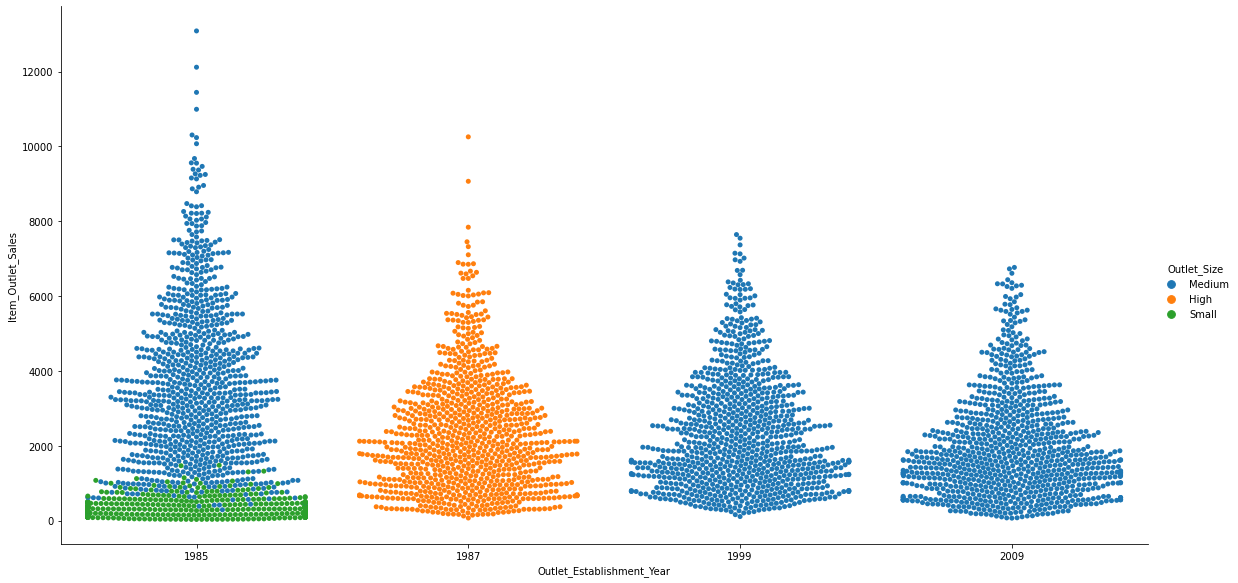

In [45]:
sns.catplot(x = 'Outlet_Establishment_Year', y = 'Item_Outlet_Sales',
            hue = 'Outlet_Size', kind = 'swarm', data = selected_years_sales_data, 
            height = 8, aspect = 2)

The data points are separated for each level of hue variable by setting dodge=True. Now the hue levels i.e Outlet Size are separated and it is done for better visualisation.

/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 16.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 32.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 37.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/python3.7/site-packages/seaborn/categorical.py:1296: UserWarning: 33.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jananiravi/opt/anaconda3/lib/

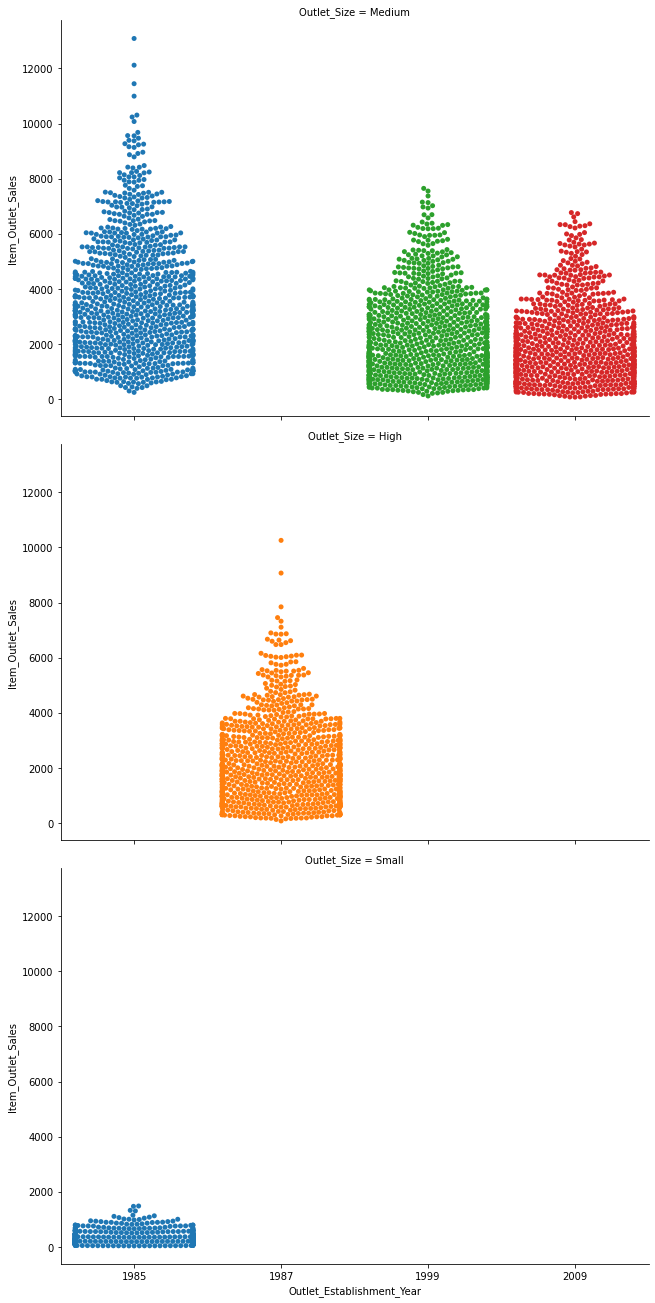

In [49]:
sns.catplot(x = 'Outlet_Establishment_Year', y = 'Item_Outlet_Sales',
            row = 'Outlet_Size', kind = 'swarm', data = selected_years_sales_data, 
            height = 6, aspect = 1.5, dodge = True)